### Install HDBSCAN clustering algorithm

In [1]:
conda install -c conda-forge hdbscan

Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
from file_loader import get_all_files
import numpy as np
import cv2
import pandas as pd
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from torchvision import transforms
from seg_rbc_crop import extract_region_attributes
from data_utils import AttributesDataset

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.manifold import TSNE
import seaborn as sns

import hdbscan

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

In [3]:
center_cells_folder = 'data/good_images_center/'
center_cells_paths = get_all_files(center_cells_folder, 'png')

In [4]:
len(center_cells_paths)

12064

In [5]:
test_df = pd.read_csv('data/test_new_clean.csv')
attributes = AttributesDataset('data/test_new_clean.csv')

print("Test size: %i" % len(test_df))
print('------------------------------------------------------------------------')
print("Size classes: ",attributes.size_labels)
print("Shape classes: ",attributes.shape_labels)
print("Hemoglobin distribution classes: ",attributes.hemo_dist_labels)

Test size: 2379
------------------------------------------------------------------------
Size classes:  ['MACR' 'MICR' 'NORM']
Shape classes:  ['ACAN' 'BITE' 'ECHI' 'ELLI' 'HELM' 'NONE' 'OVAL' 'SCHI' 'SICK' 'SPHE'
 'TEAR']
Hemoglobin distribution classes:  ['HYPO' 'HYPR' 'NONE' 'STOM' 'TARG']


### hand crafted features

In [6]:
center_cells_folder+test_df['image_name'][0]

'data/good_images_center/EH5_Siemens029/jai_0000692_794_110.png'

In [7]:
# Load and extract attributes of RBC samples
image_paths = []
shape_attributes = []
color_attribues = []
shape_color_attributes = []

gt_size_labels = []
gt_shape_labels = []
gt_hemo_dist_labels = []

for i in range(len(test_df)):
    img = cv2.imread(center_cells_folder+test_df['image_name'][i])
    matched = extract_region_attributes(img)
    
    shape_attributes.append(matched[0])
    color_attribues.append(matched[1])
    all_matched  = np.concatenate([matched[0], matched[1]])
    shape_color_attributes.append(all_matched)
    
    gt_size_labels.append(attributes.size_name_to_id[test_df['size'][i]])
    gt_shape_labels.append(attributes.shape_name_to_id[test_df['shape'][i]])
    gt_hemo_dist_labels.append(attributes.hemo_dist_name_to_id[test_df['hemo_dist'][i]])

shape_color_data = np.array(shape_color_attributes)
print(shape_color_data.shape)


(2379, 53)


In [8]:
#SIZE attributes
size_attrib_df = pd.DataFrame(shape_color_data[:,0:2], columns =['CONTOUR_AREA', 'REGION_AREA'])
size_attrib_df['ELLIPSE_MAJ_AXIS'] = shape_color_data[:,23]
size_attrib_df['ELLIPSE_MIN_AXIS'] = shape_color_data[:,24]
size_attrib_df['ELLIPSE_AR'] = shape_color_data[:,25]
size_attrib_df['ELLIPSE_PR'] = shape_color_data[:,26]
size_attrib_df['CIRCLE_R'] = shape_color_data[:,28]
size_attrib_df['CIRCLE_AR'] = shape_color_data[:,29]
size_attrib_df['RECT_MAX_DIA'] = shape_color_data[:,31]
size_attrib_df['RECT_MIN_DIA'] = shape_color_data[:,32]

#SHAPE attributes
shape_attrib_df = pd.DataFrame(shape_color_data[:,33:39], columns = ['SPLINE_CURV_MEAN', 'SPLINE_CURV_STD',\
                            'SPLINE_CURV_MAX', 'SPLINE_CURV_MIN', 'SPLINE_PROT', 'SPLINE_INDT'])

shape_attrib_df['EXTENT'] =  shape_color_data[:,2] 
shape_attrib_df['CIRCULARITY'] =  shape_color_data[:,3] 
shape_attrib_df['SOLIDITY'] =  shape_color_data[:,4] 
shape_attrib_df['CONVEXITY'] =  shape_color_data[:,5] 
shape_attrib_df['ELONGATION'] =  shape_color_data[:,6] 
shape_attrib_df['COMPACTNESS'] =  shape_color_data[:,7]

shape_attrib_df['ELLIPSE_ECC'] = shape_color_data[:,22]
shape_attrib_df['ELLIPSE_GOF'] = shape_color_data[:,27]
shape_attrib_df['CIRCLE_GOF'] = shape_color_data[:,30]

shape_attrib_df['HU_MOMENTS_BINARY_1'] = shape_color_data[:,15]
shape_attrib_df['HU_MOMENTS_BINARY_2'] = shape_color_data[:,16]
shape_attrib_df['HU_MOMENTS_BINARY_3'] = shape_color_data[:,17]
shape_attrib_df['HU_MOMENTS_BINARY_4'] = shape_color_data[:,18] 
shape_attrib_df['HU_MOMENTS_BINARY_5'] = shape_color_data[:,19]
shape_attrib_df['HU_MOMENTS_BINARY_6'] = shape_color_data[:,20]
shape_attrib_df['HU_MOMENTS_BINARY_7'] = shape_color_data[:,21]

#HEMO DIST. attributes
hemo_dist_attrib_df = pd.DataFrame(shape_color_data[:,39:], columns = ['MEAN_GRAY', 'MEAN_STD', 'MEAN_R', 'MEAN_G',\
            'MEAN_B', 'STD_R', 'STD_G', 'STD_B', 'MEAN_H', 'MEAN_S', 'MEAN_V', 'STD_H', 'STD_S', 'STD_V'])
hemo_dist_attrib_df['HU_MOMENTS_GRAY_1'] = shape_color_data[:,8]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_2'] = shape_color_data[:,9]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_3'] = shape_color_data[:,10]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_4'] = shape_color_data[:,11]    
hemo_dist_attrib_df['HU_MOMENTS_GRAY_5'] = shape_color_data[:,12]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_6'] = shape_color_data[:,13]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_7'] = shape_color_data[:,14]

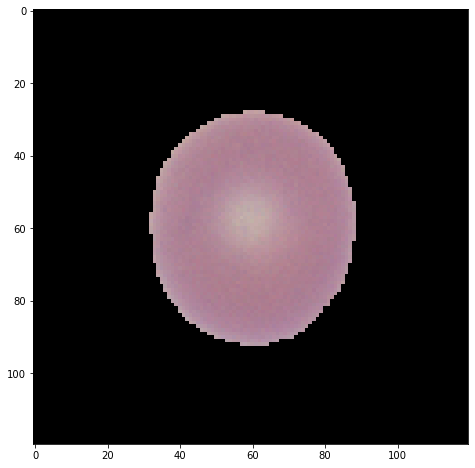

In [9]:
img = cv2.imread(center_cells_folder+test_df['image_name'][0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [10]:
size_attrib_df

,CONTOUR_AREA,REGION_AREA,ELLIPSE_MAJ_AXIS,ELLIPSE_MIN_AXIS,ELLIPSE_AR,ELLIPSE_PR,CIRCLE_R,CIRCLE_AR,RECT_MAX_DIA,RECT_MIN_DIA
0,2824.5,2912.0,64.081985,56.132030,2825.118005,189.244203,29.0,2642.079422,64.000000,56.000000
1,2175.5,2284.0,106.147331,26.801859,2234.415202,243.200624,30.0,2827.433388,102.559044,29.009935
2,3338.0,3432.0,66.136154,64.268173,3338.295476,204.859653,32.0,3216.990877,66.326622,64.488136
3,3379.5,3474.0,67.894455,63.402367,3380.879225,206.361237,32.0,3216.990877,68.000000,63.000000
4,3078.0,3168.0,63.269596,61.987793,3080.286534,196.764149,31.0,3019.070540,62.932503,62.932503
...,...,...,...,...,...,...,...,...,...,...
2374,2872.5,2960.0,64.186981,57.078133,2877.442066,190.809820,30.0,2827.433388,60.821045,59.926620
2375,3823.5,3924.0,71.109459,69.886635,3903.115332,221.484475,34.0,3631.681108,70.427757,68.761345
2376,2994.0,3084.0,66.318512,57.525223,2996.283921,195.023031,30.0,2827.433388,65.000000,57.000000
2377,3798.0,3900.0,71.178505,67.953110,3798.814432,218.606147,34.0,3631.681108,69.000000,68.000000


In [11]:
shape_attrib_df

,SPLINE_CURV_MEAN,SPLINE_CURV_STD,SPLINE_CURV_MAX,SPLINE_CURV_MIN,SPLINE_PROT,SPLINE_INDT,EXTENT,CIRCULARITY,SOLIDITY,CONVEXITY,...,ELLIPSE_ECC,ELLIPSE_GOF,CIRCLE_GOF,HU_MOMENTS_BINARY_1,HU_MOMENTS_BINARY_2,HU_MOMENTS_BINARY_3,HU_MOMENTS_BINARY_4,HU_MOMENTS_BINARY_5,HU_MOMENTS_BINARY_6,HU_MOMENTS_BINARY_7
0,0.033693,0.006753,0.054304,0.024650,0.0,0.0,0.762348,0.938459,0.984146,0.951242,...,0.482418,0.044116,0.108301,0.794401,3.369796,5.552689,7.957546,14.729027,9.662348,15.282226
1,0.032112,0.045900,0.149526,-0.021624,0.0,0.0,0.582151,0.688161,0.926139,0.948448,...,0.967598,1.224543,0.772899,0.477025,1.070482,3.252286,3.532321,6.927053,4.098489,7.901572
2,0.031127,0.005284,0.046564,0.023132,0.0,0.0,0.754862,0.941734,0.983935,0.951565,...,0.235990,0.009969,0.047038,0.797964,4.692276,7.718140,10.544913,19.753979,12.977680,19.937669
3,0.030873,0.005479,0.043652,0.020721,0.0,0.0,0.765285,0.945025,0.986715,0.954713,...,0.357698,0.022914,0.066485,0.797064,3.938589,5.663823,8.466548,16.744558,11.235637,15.532549
4,0.032464,0.005584,0.049007,0.024285,0.0,0.0,0.751648,0.942578,0.984960,0.952530,...,0.200271,0.007683,0.043991,0.797990,5.009796,5.733412,9.595154,17.346338,12.101384,17.500305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,0.033567,0.006464,0.049342,0.021468,0.0,0.0,0.749022,0.938652,0.985251,0.951616,...,0.457426,0.038920,0.090546,0.795000,3.461324,5.649559,8.178011,15.183898,10.177305,15.322463
2375,0.029066,0.011077,0.055367,-0.000600,0.0,0.0,0.707793,0.926082,0.981643,0.949284,...,0.184654,0.021905,0.106719,0.793051,5.090172,3.834934,6.523149,11.775424,9.131321,11.973803
2376,0.032526,0.006224,0.051037,0.025191,0.0,0.0,0.782132,0.944629,0.987467,0.958858,...,0.497597,0.047513,0.120749,0.793473,3.305585,5.091401,7.214495,13.464403,8.955070,13.589202
2377,0.028934,0.004559,0.039562,0.019918,0.0,0.0,0.786335,0.942378,0.988548,0.952290,...,0.297615,0.014839,0.051676,0.797578,4.280133,7.006913,10.007951,18.938049,12.153498,18.548837


In [12]:
hemo_dist_attrib_df

,MEAN_GRAY,MEAN_STD,MEAN_R,MEAN_G,MEAN_B,STD_R,STD_G,STD_B,MEAN_H,MEAN_S,...,STD_H,STD_S,STD_V,HU_MOMENTS_GRAY_1,HU_MOMENTS_GRAY_2,HU_MOMENTS_GRAY_3,HU_MOMENTS_GRAY_4,HU_MOMENTS_GRAY_5,HU_MOMENTS_GRAY_6,HU_MOMENTS_GRAY_7
0,148.663934,7.946347,151.133607,133.940164,176.643443,6.396799,10.032882,5.496265,164.145902,61.913115,...,24.610074,9.242134,5.496265,2.971866,7.745318,11.965265,13.112534,25.803933,17.072948,25.799982
1,142.831609,9.400405,152.202299,130.448851,163.583908,6.245863,11.723600,7.554961,158.451724,52.333333,...,19.953667,10.247194,7.388151,2.647421,5.415412,9.719569,9.970246,19.816522,12.702533,20.916112
2,142.691570,9.490885,149.870459,127.303633,170.160727,7.880426,11.601756,6.878701,160.995202,64.632625,...,22.160530,9.811698,6.878701,2.957499,8.996552,14.094070,14.935174,30.525037,19.754829,29.451338
3,129.484787,6.019093,145.894523,119.246450,143.334686,5.616764,6.749436,6.163664,147.898580,48.001014,...,5.412703,8.582279,5.794486,2.915774,8.133772,11.911540,13.519484,26.991282,17.730547,26.241772
4,142.781893,10.091535,149.541339,128.821175,167.630378,8.561952,12.600431,6.784503,158.592593,59.677516,...,27.692457,10.778038,6.784041,2.957402,9.378418,12.175735,13.870728,27.221004,18.654748,26.948406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,135.522984,17.617288,136.612097,127.818145,150.209677,13.786547,20.257306,14.743738,137.550000,41.522177,...,59.538500,9.863193,14.592980,2.945521,7.764411,12.127719,13.719798,26.722958,17.767611,26.900513
2375,117.710919,7.554987,146.359487,109.519093,122.868735,4.845581,8.390790,8.080521,131.196897,64.235084,...,2.957336,12.314964,4.845968,2.872081,9.288505,10.098367,12.445982,24.233039,17.125136,23.739443
2376,134.578725,22.990438,149.375192,122.202381,153.231183,16.516115,26.516800,19.192541,153.812596,55.984255,...,13.947600,20.154190,17.947098,2.951114,7.627163,11.467657,12.574071,24.665064,16.396851,24.874484
2377,128.498214,18.398531,147.528571,117.789286,142.281250,13.962420,21.146223,15.283951,144.754167,53.717857,...,12.487386,16.864891,14.530792,2.928184,8.503561,13.276187,13.979354,27.685311,18.448514,27.866857


### Unsupervised learning  - SIZE

In [13]:
X_input = size_attrib_df.to_numpy()

In [14]:
X_input.shape

(2379, 10)

                 0            1            2            3            4  \
count  2379.000000  2379.000000  2379.000000  2379.000000  2379.000000   
mean   2993.211223  3084.304330    67.462999    56.728644  3019.717982   
std     661.072410   669.980909     8.684761     8.293003   651.573476   
min     713.500000   759.000000    31.545008    24.694206   718.911876   
25%    2611.500000  2696.000000    61.976917    52.917259  2632.834334   
50%    2963.500000  3053.000000    66.580864    57.721207  2981.360291   
75%    3359.000000  3455.500000    72.188553    61.767475  3381.206234   
max    6133.000000  6264.000000   114.318977    83.582184  6173.056099   

                 5            6            7            8            9  
count  2379.000000  2379.000000  2379.000000  2379.000000  2379.000000  
mean    196.467201    30.350147  2930.400771    66.392966    57.668143  
std      21.273280     3.413063   643.916801     8.632877     8.269842  
min      95.213687    15.000000   706.858

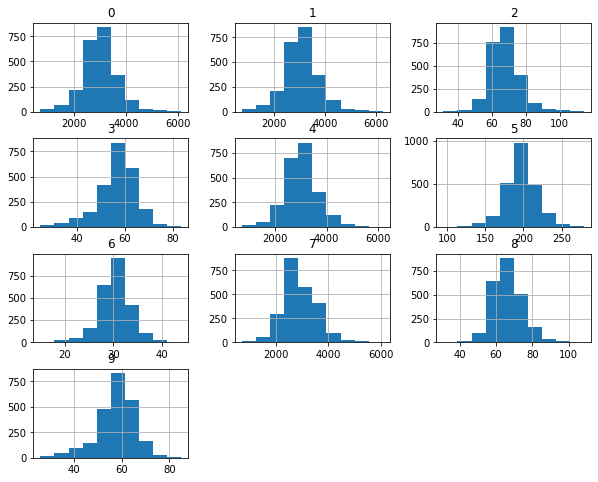

In [15]:
dataset = pd.DataFrame(X_input)
# summarize
print(dataset.describe())
# histograms of the variables
dataset.hist()
plt.show()

In [16]:
np.bincount(gt_size_labels)

array([  39,  249, 2091])

#### Dimensíonality reduction PCA

[0.83629488 0.15402141]


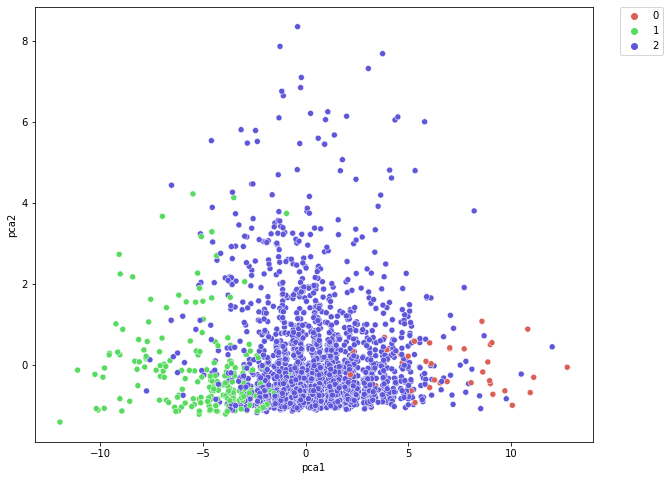

In [17]:
X = StandardScaler().fit_transform(X_input)   
pca = PCA(n_components=2) 
X_trans = pca.fit_transform(X)
print(pca.explained_variance_ratio_)

df_pca = pd.DataFrame(data = X_trans, columns = ['pca1','pca2'])
sns.scatterplot(x="pca1", y="pca2", hue=np.array(gt_size_labels), data=df_pca, palette=sns.color_palette("hls", 3))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)

#### Dimensionality reduction t-SNE

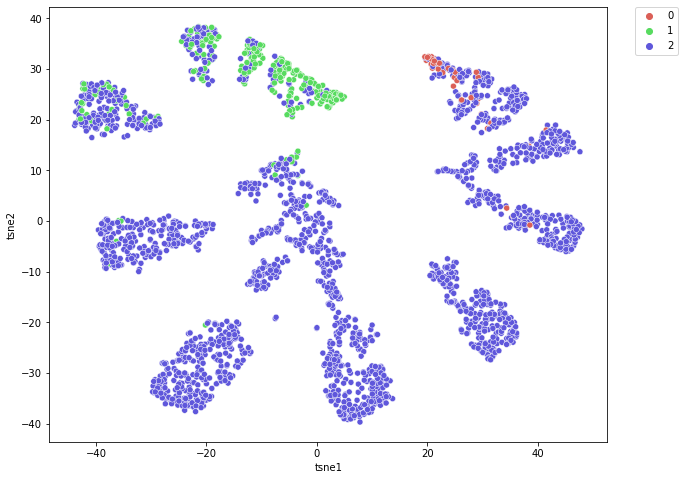

In [23]:
X = StandardScaler().fit_transform(X_input) 
X_tsne = TSNE(n_components=2,perplexity=50).fit_transform(X)

df_tsne = pd.DataFrame(data = X_tsne, columns = ['tsne1','tsne2'])

sns.scatterplot(x="tsne1", y="tsne2", hue=np.array(gt_size_labels), data=df_tsne, palette=sns.color_palette("hls", 3))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)

## HDBSCAN Clustering

In [24]:
clusterer = hdbscan.HDBSCAN(min_cluster_size =50)
X = StandardScaler().fit_transform(X_tsne)
cluster_labels = clusterer.fit_predict(X_tsne)
cluster_labels =cluster_labels + 1
print(cluster_labels)                               #cluster with label 0 is outlier
bc = np.bincount(cluster_labels[cluster_labels>=0])
print(bc)
print(len(bc))
num_clusters = len(bc) 
print(bc.sum())

[5 7 2 ... 6 3 3]
[ 70 192 228 554 309 235 277 260 254]
9
2379


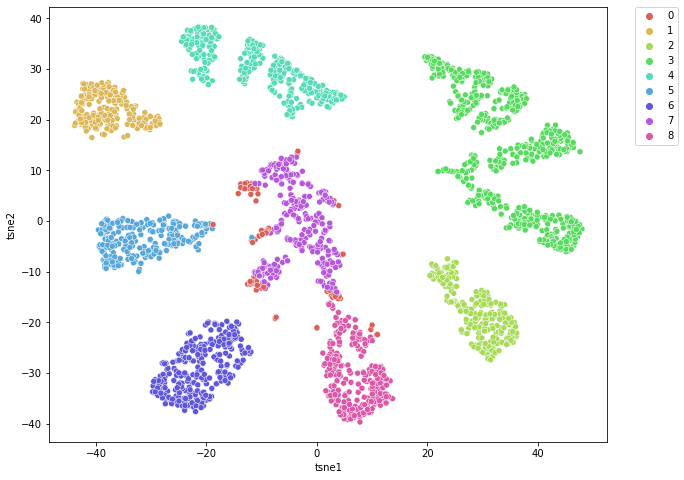

In [25]:
if (bc[0]==0):                           #If no outliers are present, reduce number of clusters by 1
    num_clusters =num_clusters-1

cluster_labels1 = cluster_labels[..., np.newaxis]
X_tsne1 = np.append(X_tsne, cluster_labels1, axis=1)

df_tsne = pd.DataFrame(data = X_tsne1, columns = ['tsne1','tsne2','labels'])
df_tsne['labels'] = df_tsne['labels'].astype(int)

sns.scatterplot(x="tsne1", y="tsne2", hue="labels", data=df_tsne, palette=sns.color_palette("hls", num_clusters))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)

#### Visualization of Size Clusters

cluster  0


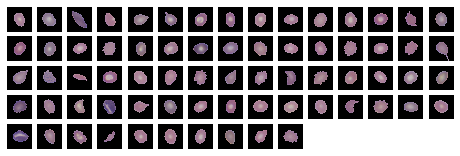

cluster  1


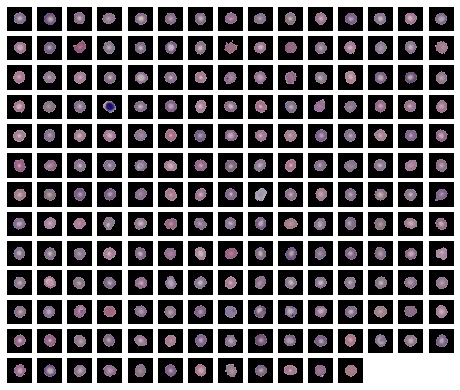

cluster  2


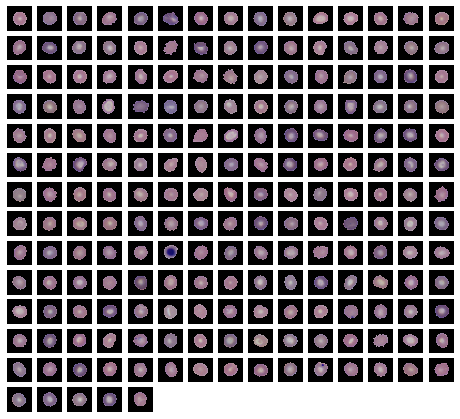

cluster  3


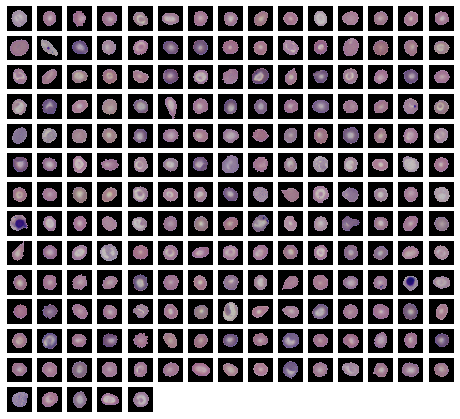

cluster  4


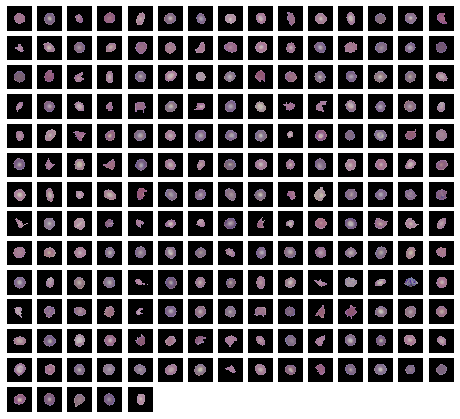

cluster  5


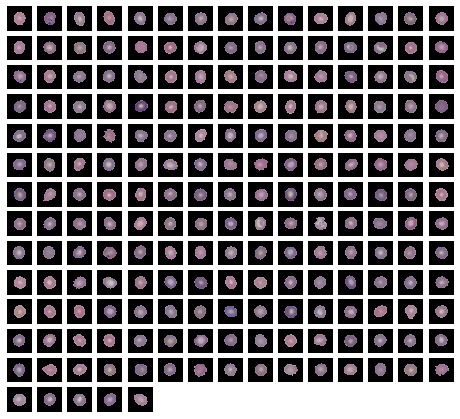

cluster  6


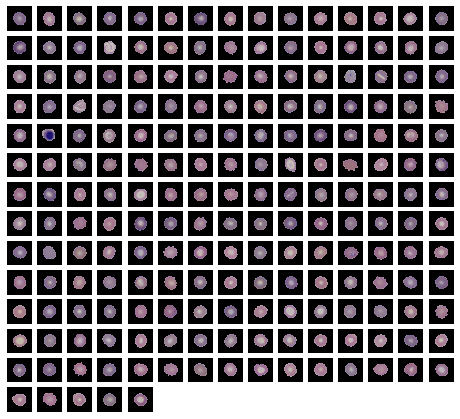

cluster  7


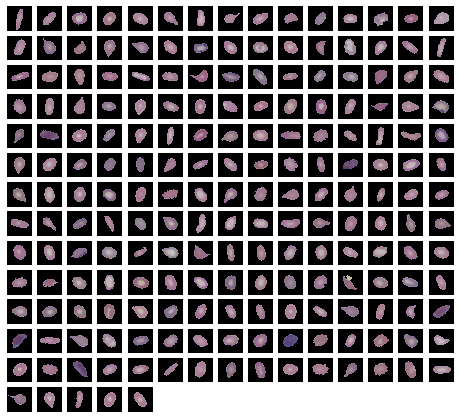

cluster  8


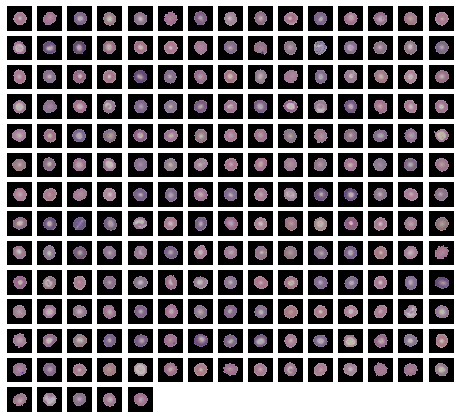

In [26]:
for k in range(0,num_clusters):                   #cluster 0 is outliers
    loc = np.where(cluster_labels==k)
    loc = np.array(loc).squeeze()
    if(len(loc)>200):
        loc=loc[0:200]
    #print(loc)
    print("cluster ", k)
    w =10
    h =10
    fig =plt.figure(figsize = (8,8))
    columns = 15
    rows = 15
    if(np.size(loc) ==1):
        image = cv2.imread(image_paths[loc])
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        fig.add_subplot(rows,columns,1)
        plt.imshow(img)
        plt.axis('off')
    else:    
        for i,l in enumerate(loc,1):
            image = cv2.imread(center_cells_folder+test_df['image_name'][l])
            img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            fig.add_subplot(rows,columns,i)
            plt.imshow(img)
            plt.axis('off')
    plt.show()    

## Classification using SVM

In [27]:
# Load and extract attributes of RBC samples
data_df = pd.read_csv('data/all_data_new_clean1.csv')
print(len(data_df))
image_paths = []
shape_attributes = []
color_attribues = []
shape_color_attributes = []

gt_size_labels = []
gt_shape_labels = []
gt_hemo_dist_labels = []

for i in range(len(data_df)):
    img = cv2.imread(center_cells_folder+data_df['image_name'][i])
    matched = extract_region_attributes(img)
    
    shape_attributes.append(matched[0])
    color_attribues.append(matched[1])
    all_matched  = np.concatenate([matched[0], matched[1]])
    shape_color_attributes.append(all_matched)
    
    gt_size_labels.append(attributes.size_name_to_id[data_df['size'][i]])
    gt_shape_labels.append(attributes.shape_name_to_id[data_df['shape'][i]])
    gt_hemo_dist_labels.append(attributes.hemo_dist_name_to_id[data_df['hemo_dist'][i]])

shape_color_data = np.array(shape_color_attributes)
print(shape_color_data.shape)


11891
(11891, 53)


In [28]:
#SIZE attributes
size_attrib_df = pd.DataFrame(shape_color_data[:,0:2], columns =['CONTOUR_AREA', 'REGION_AREA'])
size_attrib_df['ELLIPSE_MAJ_AXIS'] = shape_color_data[:,23]
size_attrib_df['ELLIPSE_MIN_AXIS'] = shape_color_data[:,24]
size_attrib_df['ELLIPSE_AR'] = shape_color_data[:,25]
size_attrib_df['ELLIPSE_PR'] = shape_color_data[:,26]
size_attrib_df['CIRCLE_R'] = shape_color_data[:,28]
size_attrib_df['CIRCLE_AR'] = shape_color_data[:,29]
size_attrib_df['RECT_MAX_DIA'] = shape_color_data[:,31]
size_attrib_df['RECT_MIN_DIA'] = shape_color_data[:,32]

#SHAPE attributes
shape_attrib_df = pd.DataFrame(shape_color_data[:,33:39], columns = ['SPLINE_CURV_MEAN', 'SPLINE_CURV_STD',\
                            'SPLINE_CURV_MAX', 'SPLINE_CURV_MIN', 'SPLINE_PROT', 'SPLINE_INDT'])

shape_attrib_df['EXTENT'] =  shape_color_data[:,2] 
shape_attrib_df['CIRCULARITY'] =  shape_color_data[:,3] 
shape_attrib_df['SOLIDITY'] =  shape_color_data[:,4] 
shape_attrib_df['CONVEXITY'] =  shape_color_data[:,5] 
shape_attrib_df['ELONGATION'] =  shape_color_data[:,6] 
shape_attrib_df['COMPACTNESS'] =  shape_color_data[:,7]

shape_attrib_df['ELLIPSE_ECC'] = shape_color_data[:,22]
shape_attrib_df['ELLIPSE_GOF'] = shape_color_data[:,27]
shape_attrib_df['CIRCLE_GOF'] = shape_color_data[:,30]

shape_attrib_df['HU_MOMENTS_BINARY_1'] = shape_color_data[:,15]
shape_attrib_df['HU_MOMENTS_BINARY_2'] = shape_color_data[:,16]
shape_attrib_df['HU_MOMENTS_BINARY_3'] = shape_color_data[:,17]
shape_attrib_df['HU_MOMENTS_BINARY_4'] = shape_color_data[:,18] 
shape_attrib_df['HU_MOMENTS_BINARY_5'] = shape_color_data[:,19]
shape_attrib_df['HU_MOMENTS_BINARY_6'] = shape_color_data[:,20]
shape_attrib_df['HU_MOMENTS_BINARY_7'] = shape_color_data[:,21]

#HEMO DIST. attributes
hemo_dist_attrib_df = pd.DataFrame(shape_color_data[:,39:], columns = ['MEAN_GRAY', 'MEAN_STD', 'MEAN_R', 'MEAN_G',\
            'MEAN_B', 'STD_R', 'STD_G', 'STD_B', 'MEAN_H', 'MEAN_S', 'MEAN_V', 'STD_H', 'STD_S', 'STD_V'])
hemo_dist_attrib_df['HU_MOMENTS_GRAY_1'] = shape_color_data[:,8]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_2'] = shape_color_data[:,9]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_3'] = shape_color_data[:,10]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_4'] = shape_color_data[:,11]    
hemo_dist_attrib_df['HU_MOMENTS_GRAY_5'] = shape_color_data[:,12]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_6'] = shape_color_data[:,13]
hemo_dist_attrib_df['HU_MOMENTS_GRAY_7'] = shape_color_data[:,14]

## SVM - SIZE classifier

In [29]:
X_inp = size_attrib_df.to_numpy()
X = StandardScaler().fit_transform(X_inp) 

y = np.array(gt_size_labels)
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=2)
print('Training set size: ', X_train.shape)
print('Test set size: ', X_test.shape)

Training set size:  (9512, 10)
Test set size:  (2379, 10)


SVM Accuracy Score: 
0.8743169398907104
SVM Confusion Matrix:
[[  32    0    7]
 [   0  219   30]
 [ 105  157 1829]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.82      0.36        39
           1       0.58      0.88      0.70       249
           2       0.98      0.87      0.92      2091

    accuracy                           0.87      2379
   macro avg       0.60      0.86      0.66      2379
weighted avg       0.93      0.87      0.89      2379



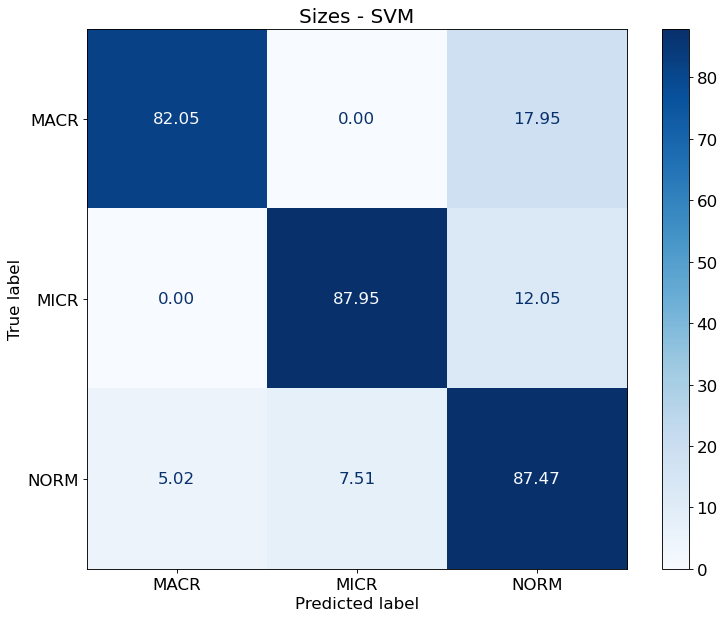

In [30]:
# Train SVM classifier - size
svclassifier = SVC(kernel='poly', class_weight='balanced')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

# prediction results
print('SVM Accuracy Score: ')
print(accuracy_score(y_test, y_pred))
print('SVM Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('SVM Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        normalize='true')
cm = (cm.astype('float') / cm.astype('float').sum(axis=1)[:, np.newaxis])*100

fmt = '.2f'
plt.rcParams.update({'font.size': 15})
plt.rcParams.update({'figure.dpi': 80})
#plt.rcParams['figure.figsize']=(10,10)
#plt.rcParams.update({'font.size': 15})
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attributes.size_labels)
disp.plot(xticks_rotation='horizontal', values_format=fmt, cmap=plt.cm.Blues )
plt.title("Sizes - SVM")
plt.tight_layout()
plt.show()

## SVM - SHAPE classifier

In [31]:
X_inp = shape_attrib_df.to_numpy()
X = StandardScaler().fit_transform(X_inp) 
y = np.array(gt_shape_labels)
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=2)
print('Training set size: ', X_train.shape)
print('Test set size: ', X_test.shape)

Training set size:  (9512, 22)
Test set size:  (2379, 22)


SVM Accuracy Score: 
0.8621269440941572
SVM Confusion Matrix:
[[  16    0    8    0    3    1    0    2    0    0    0]
 [   0    0    0    0    0    2    1    0    0    0    0]
 [  21    3   80    0    1   42    2    1    0    0    0]
 [   0    0    0   21    0    0    2    0    0    0    0]
 [   0    0    0    0   19    0    0    4    0    0    0]
 [   1   15    7    0   11 1707   37    1    0   79   27]
 [   0    1    3    8    0    6  100    0    2    0    7]
 [   3    0    0    0    5    1    1   23    0    0    0]
 [   0    0    0    2    0    0    1    0    4    0    0]
 [   0    0    0    0    0    8    0    0    0    3    0]
 [   0    1    0    0    2    3    0    2    1    0   78]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.53      0.45        30
           1       0.00      0.00      0.00         3
           2       0.82      0.53      0.65       150
           3       0.68      0.91      0.78        23
 

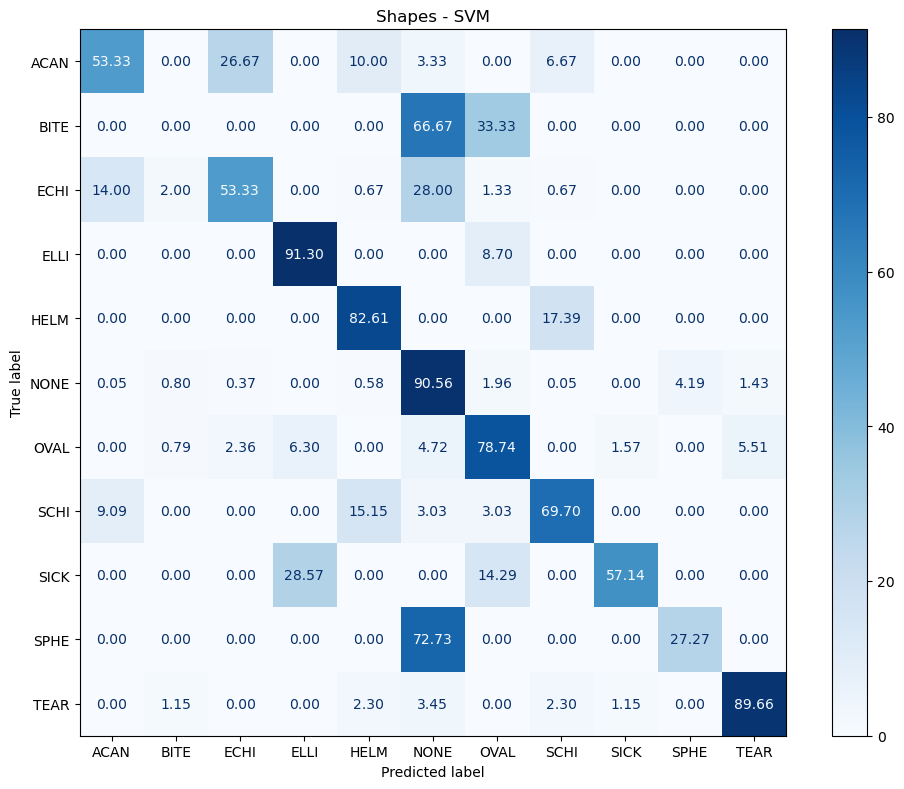

In [32]:
# Train SVM classifier - shape
svclassifier = SVC(kernel='poly', class_weight='balanced')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

# prediction results
print('SVM Accuracy Score: ')
print(accuracy_score(y_test, y_pred))
print('SVM Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('SVM Classification Report:')
print(classification_report(y_test, y_pred))

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.dpi': 100})
cm = confusion_matrix(y_test, y_pred, normalize='true')
cm = (cm.astype('float') / cm.astype('float').sum(axis=1)[:, np.newaxis])*100

fmt = '.2f'
disp = ConfusionMatrixDisplay(cm, display_labels=attributes.shape_labels)
disp.plot(values_format=fmt,xticks_rotation='horizontal', cmap=plt.cm.Blues)
plt.title("Shapes - SVM")
plt.tight_layout()
plt.show()

## SVM - Hemoglobin dist. classifier

In [33]:
X_inp = hemo_dist_attrib_df.to_numpy()
X = StandardScaler().fit_transform(X_inp) 
y = np.array(gt_hemo_dist_labels)
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=2)
print('Training set size: ', X_train.shape)
print('Test set size: ', X_test.shape)

Training set size:  (9512, 21)
Test set size:  (2379, 21)


SVM Accuracy Score: 
0.7145859604875998
SVM Confusion Matrix:
[[ 148    1   33    4   36]
 [   0   74   29    2    1]
 [  95  296 1422  102   45]
 [   0    1    6    7    2]
 [   4    3   17    2   49]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63       222
           1       0.20      0.70      0.31       106
           2       0.94      0.73      0.82      1960
           3       0.06      0.44      0.11        16
           4       0.37      0.65      0.47        75

    accuracy                           0.71      2379
   macro avg       0.43      0.64      0.47      2379
weighted avg       0.85      0.71      0.76      2379



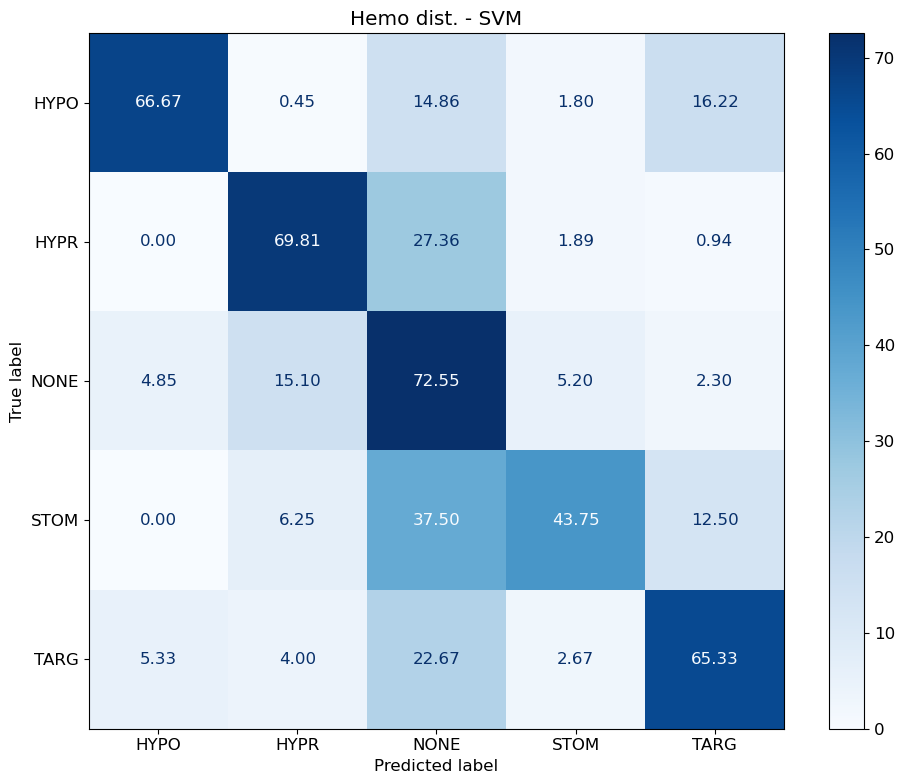

In [34]:
# Train SVM classifier - hemoglobin distribution
svclassifier = SVC(kernel='poly', class_weight='balanced')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

# prediction results
print('SVM Accuracy Score: ')
print(accuracy_score(y_test, y_pred))
print('SVM Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('SVM Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true')
cm = (cm.astype('float') / cm.astype('float').sum(axis=1)[:, np.newaxis])*100

fmt = '.2f'
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'figure.dpi': 100})
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attributes.hemo_dist_labels)
disp.plot(values_format=fmt,xticks_rotation='horizontal', cmap=plt.cm.Blues)
plt.title("Hemo dist. - SVM")
plt.tight_layout()
plt.show()